In [252]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tableone import TableOne, load_dataset
from datetime import datetime
from functools import reduce

In [253]:
#Loading .csv files with subtyping information
subtype = pd.read_csv("/Users/estefanyguzman/Documents/Northwestern/PhD/Thesis-Work/Clinical-Analysis/LCH/092425-LCH-subtype-info.csv")
#Loading the dataframe with all the LCH encounters
lch = pd.read_csv("021826-LCH-dataset-uniq-filtered.csv")
#Loading the "official breakthrough cases"
#breakthrough = pd.read_csv("")

In [254]:
subtype
lch = subtype.merge(lch, on="study_id", how="left")

In [255]:
#Dropping identical patient encounters (had information about low or high flow omitted prior to loading data)
lch = lch.drop_duplicates()

#Pulling only encounters with RSV information
lch['component name'].unique()

#Setting list for RSV positive specimen
RSV_pos = ['RESPIRATORY SYNCYTIAL VIRUS', 'RSV BY PCR']

# Select rows where 'column_name' is in the specific_values_list
lch_rsv = lch.loc[lch['component name'].isin(RSV_pos)]

#Dropping two samples since we are only looking at unique patient encounters
lch_rsv_uniq = lch_rsv[~lch_rsv["study_id"].isin(["LCH13344", "LCH15786"])]

In [189]:
#Checking to see if there are any duplicate patients
dupes = lch_rsv_uniq[lch_rsv_uniq["patient_mrn"].duplicated(keep=False)]
dupes #no duplicates in the dataset

,study_id,subtype,patient_mrn,birth_date,sex,race,ethnicity,coi_chi_metro,coi_national,coi_state,...,study_id.2,Nirsevimab,Nirsevimab_el,Healthy,Prematurity_Lung,Other_Chronic Lung,Cardiac,Immuncompromised,Other,Unnamed: 74


In [190]:
#There are 342 total encounters we initially requested, we removed 2 separate encounters for 2 longitudinal samples
#from Sameer: LCH12826 has no data in EPIC, LCH13325 does not exist in EPCI
#Total: 342 - 2 (dup) - 2 (missing data) = 338 patient encounters listed below
# Check duplicates "LCH13344", "LCH15786"

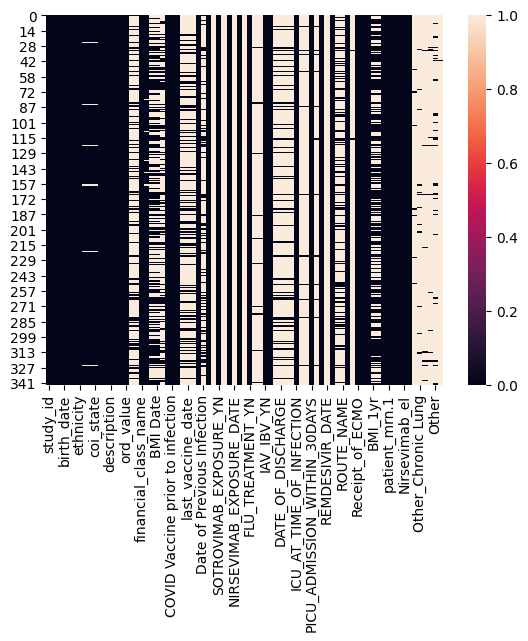

In [191]:
general_heatmap = lch_rsv_uniq.isnull()
inpatient_adult_hm = sns.heatmap(general_heatmap)

In [192]:
#dropping COI data
lch_red = lch_rsv_uniq.drop(['coi_chi_metro', 'coi_national', 'coi_state'], axis=1)

In [193]:
lch_red['DEATH_DATE'] = lch_red['DEATH_DATE'].fillna(0)

cols = ['DEATH_DATE']

lch_red[cols] = (
    lch_red[cols]
    .fillna(0)
    .replace({0: 'absent', 1: 'present'}))

In [194]:
lch_red['DEATH_DATE'].unique()

array(['absent', '1/18/25 4:05', '12/4/24 13:54'], dtype=object)

In [195]:
#Making categories for hospitalized, not hospitalized, PICU, & Death (currently do not have death)
#Establishing a category for each of the patients
lch_red['Category'] =''
lch_red['Category'] = np.where((lch_red['HOSPITALIZATION'] == 'Y') & (lch_red['PICU_ADMISSION_WITHIN_30DAYS'] == 'Y'), 'PICU', lch_red['Category'])
lch_red['Category'] = np.where((lch_red['HOSPITALIZATION'] == 'Y') & (lch_red['PICU_ADMISSION_WITHIN_30DAYS'] == 'N'), 'Hospitalized, No PICU', lch_red['Category'])
lch_red['Category'] = np.where((lch_red['HOSPITALIZATION'] == 'N') & (lch_red['PICU_ADMISSION_WITHIN_30DAYS'] == 'N'), 'No Hospitalization', lch_red['Category'])
lch_red['Category'] = np.where((lch_red['HOSPITALIZATION'] == 'N') & (lch_red['PICU_ADMISSION_WITHIN_30DAYS'] == 'N'), 'No Hospitalization', lch_red['Category'])
lch_red['Category'] = np.where((lch_red['DEATH_DATE'] != 'absent'), 'Death', lch_red['Category'])

In [196]:
lch_red['Category'].unique()

array(['No Hospitalization', 'PICU', 'Hospitalized, No PICU', 'Death'],
      dtype=object)

In [197]:
#Defining Hospitalization LOS
lch_red['DATE_OF_HOSPITALIZATION'] = pd.to_datetime(lch_red['DATE_OF_HOSPITALIZATION'])
lch_red['DATE_OF_DISCHARGE'] = pd.to_datetime(lch_red['DATE_OF_DISCHARGE'])
lch_red['day_hosp'] = (lch_red['DATE_OF_DISCHARGE'] - lch_red['DATE_OF_HOSPITALIZATION']).dt.days
#lch_red[lch_red['day'] == 59]
#Defining PICU LOS
lch_red['PICU_ADMISSION_DATE_14DAYS'] = pd.to_datetime(lch_red['PICU_ADMISSION_DATE_14DAYS'])
lch_red['PICU_DISCHARGE_DATE_14DAYS'] = pd.to_datetime(lch_red['PICU_DISCHARGE_DATE_14DAYS'])
lch_red['day_PICU'] = (lch_red['PICU_DISCHARGE_DATE_14DAYS'] - lch_red['PICU_ADMISSION_DATE_14DAYS']).dt.days
lch_red['day_PICU'].unique()

array([nan,  4.,  2.,  1., 13.,  5., 18.])

In [198]:
lch_red['day_hosp'].unique()

array([nan,  4.,  3., 20.,  1.,  2.,  0.,  7., 13.,  8.,  5., 59., 27.,
       18.])

Text(0.5, 1.0, 'LCH Age Distribution')

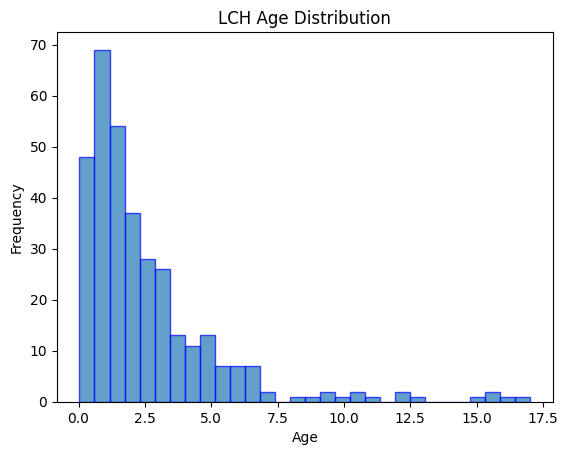

In [199]:
#Defining age at time of encounter
lch_red['date of index infection'] = pd.to_datetime(lch_red['date of index infection'])
lch_red['birth_date'] = pd.to_datetime(lch_red['birth_date'])
lch_red['age'] = (lch_red['date of index infection'] - lch_red['birth_date']).dt.days
#lch_red['age']/365
plt.hist(lch_red['age']/365, bins=30, edgecolor='blue', alpha=0.7)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("LCH Age Distribution")

In [200]:
#Generating Age in Days, Months, and Years
average_days_per_month = 30.44
lch_red['months'] = (lch_red['age'] / average_days_per_month).astype(int)
lch_red['years'] = (lch_red['months']/12).apply(np.floor)

In [201]:
#Age Group Stratification
lch_red['Age Group'] =''
lch_red['Age Group'] = np.where((lch_red['months'] >= 0) & 
                                      (lch_red['months'] < 3), 
                                      '0 - 3 months', lch_red['Age Group'])
lch_red['Age Group'] = np.where((lch_red['months'] >= 3) & 
                                      (lch_red['months'] < 6), 
                                      '3 - 6 months', lch_red['Age Group'])
lch_red['Age Group'] = np.where((lch_red['months'] >= 6) & 
                                      (lch_red['months'] < 12), 
                                      '6 - 12 months', lch_red['Age Group'])
lch_red['Age Group'] = np.where((lch_red['months'] >= 12) & 
                                      (lch_red['months'] < 24), 
                                      '1 - 2 years', lch_red['Age Group'])
lch_red['Age Group'] = np.where((lch_red['months'] >= 24) & 
                                      (lch_red['months'] < 60), 
                                      '2 - 5 years', lch_red['Age Group'])
lch_red['Age Group'] = np.where((lch_red['months'] >= 60) & 
                                      (lch_red['months'] < 120), 
                                      '5 - 10 years', lch_red['Age Group'])
lch_red['Age Group'] = np.where((lch_red['months'] >= 120) & 
                                      (lch_red['months'] < 216), 
                                      '10 - 18 years', lch_red['Age Group'])

NameError: name 'merged_df' is not defined

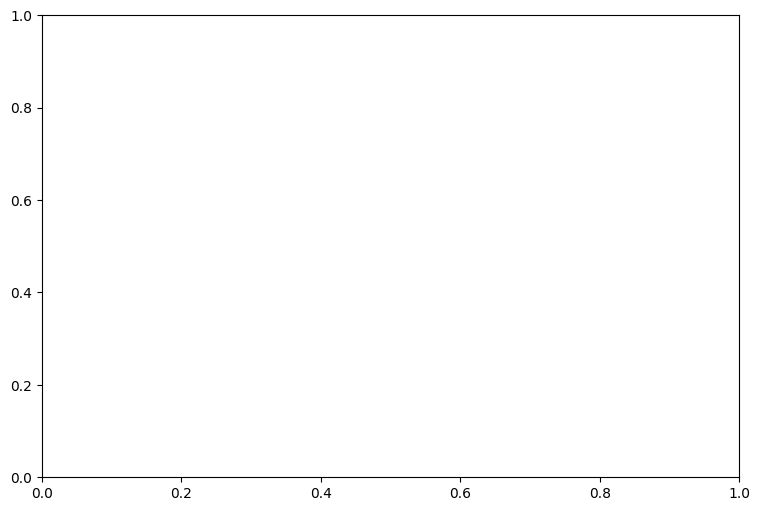

In [46]:
#Merge Subtyping Information 
#Loading subtybe information
subtype = pd.read_csv("/Users/estefanyguzman/Documents/Northwestern/PhD/Thesis-Work/Clinical-Analysis/LCH/092425-LCH-subtype-info.csv")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Your age order
age_group = ['0-3 months', '6-12 months', '1-2 years', '2-5 years',
             '5-10 years', '10-18 years', '18 - 60 years', '60-65 years',
             '65-75 years', '75-older']

fig, ax = plt.subplots(figsize=(9, 6))

# Draw the violinplot
sns.violinplot(x='Age_group', y='CT', data=merged_df,
               order=age_group, inner=None, ax=ax)  # inner=None hides default bars

# Draw the median line manually
medians = merged_df.groupby('Age_group')['CT'].median().reindex(age_group)

for i, median in enumerate(medians):
    ax.plot([i - 0.3, i + 0.3], [median, median], color='white', linewidth=2)

# Optional: overlay stripplot
sns.stripplot(x="Age_group", 
              y="CT", 
              data=merged_df, 
              jitter=True, 
              ax=ax,  
              edgecolor='black',
              order=age_group,
              linewidth=0.5)

plt.xticks(rotation=45, ha='right')
sns.despine(left=True)
plt.show()

In [202]:
#Making comorbidities into categories
lch_red['Immuncompromised'].isna()

lch_red['Immuncompromised'] = lch_red['Immuncompromised'].fillna(0)

lch_red['Healthy'] = lch_red['Healthy'].fillna(0)

lch_red['Prematurity_Lung '] = lch_red['Prematurity_Lung '].fillna(0)

lch_red['Other_Chronic Lung'] = lch_red['Other_Chronic Lung'].fillna(0)

lch_red['Cardiac'] = lch_red['Cardiac'].fillna(0)

lch_red['Other'] = lch_red['Other'].fillna(0)

In [203]:
cols = ['Healthy', 'Prematurity_Lung ', 'Other_Chronic Lung','Cardiac','Immuncompromised','Other']

lch_red[cols] = (
    lch_red[cols]
    .fillna(0)
    .replace({0: 'absent', 1: 'present'}))

cols = ['Prematurity_Lung ', 'Other_Chronic Lung','Cardiac','Immuncompromised','Other']

lch_red['prematurity_comorbidity_sum'] = (lch_red[cols] == 'present').sum(axis=1)
lch_red['prematurity_comorbidity_sum'].unique()

array([0, 1, 2, 3, 4])

In [204]:
#Making categories for hospitalized, not hospitalized, PICU, & Death (currently do not have death)
#Establishing a category for each of the patients
lch_red['Category'] =''
lch_red['Category'] = np.where((lch_red['HOSPITALIZATION'] == 'Y') & (lch_red['PICU_ADMISSION_WITHIN_30DAYS'] == 'Y'), 'PICU', lch_red['Category'])
lch_red['Category'] = np.where((lch_red['HOSPITALIZATION'] == 'Y') & (lch_red['PICU_ADMISSION_WITHIN_30DAYS'] == 'N'), 'Hospitalized, No PICU', lch_red['Category'])
lch_red['Category'] = np.where((lch_red['HOSPITALIZATION'] == 'N') & (lch_red['PICU_ADMISSION_WITHIN_30DAYS'] == 'N'), 'No Hospitalization', lch_red['Category'])
lch_red['Category'] = np.where((lch_red['HOSPITALIZATION'] == 'N') & (lch_red['PICU_ADMISSION_WITHIN_30DAYS'] == 'N'), 'No Hospitalization', lch_red['Category'])
lch_red['Category'] = np.where((lch_red['DEATH_DATE'] != 'absent'), 'Death', lch_red['Category'])

In [205]:
final_dem_df= lch_red[['study_id',
                       'years',
                       'months',
                      'Age Group',
                       'birth_date',
                       'date of index infection',
                    'race',
                    'ethnicity',
                     'sex',
                     'Category',
                       'day_hosp',
                       'prematurity_comorbidity_sum',
                       'subtype',
                         'Nirsevimab_el',
                         'Healthy',
                         'Prematurity_Lung ',
                         'Other_Chronic Lung',
                         'Cardiac',
                         'Immuncompromised',
                         'Other',
                     'CCC?']].copy()

In [206]:
#Creating Columns for Demographics Table
columns = ['Age Group',
                    'race',
                    'ethnicity',
                     'sex',
                     'Category',
           'subtype',
           'Nirsevimab_el',
                         'Healthy',
                         'Prematurity_Lung ',
                         'Other_Chronic Lung',
                         'Cardiac',
                         'Immuncompromised',
                         'Other']
#groupby = [''] #you can categorize by different groupings

In [207]:
final_dem_df['Category'].unique()

array(['No Hospitalization', 'PICU', 'Hospitalized, No PICU', 'Death'],
      dtype=object)

In [208]:
from tableone import TableOne, load_dataset
#calculate whether deaths were within a certain timeframe after leaving hospital
mytable = TableOne(final_dem_df, columns=columns) ##Add groupby=groupby, pval=true when you know how to group by
print(mytable.tabulate(tablefmt = "fa"))
#mytable.to_excel('031026-dem-LCH-v1.xlsx')

                                                             Missing    Overall
-------------------------  --------------------------------  ---------  ----------
n                                                                       338
Age Group, n (%)           0 - 3 months                      0          16 (4.7)
                           1 - 2 years                                  91 (26.9)
                           10 - 18 years                                12 (3.6)
                           2 - 5 years                                  109 (32.2)
                           3 - 6 months                                 25 (7.4)
                           5 - 10 years                                 30 (8.9)
                           6 - 12 months                                55 (16.3)
race, n (%)                1-WHITE                           0          88 (26.0)
                           10-DECLINED                                  5 (1.5)
                           2

In [176]:
#final_dem_df.to_csv("/Users/estefanyguzman/Documents/Northwestern/PhD/Manuscripts/RSV_Follow-up_manuscript/Table-2_Ped-Demographics/030126-LCH-demographics.csv")

# Excluding Unknown and Ineligible Patients to Run Model

In [209]:
final_dem_df_nir = final_dem_df[
    (final_dem_df['Nirsevimab_el'] == 'Yes') | 
    (final_dem_df['Nirsevimab_el'] == 'No')
]

In [211]:
#Condensing Some of the parameters with low events for model
#Dropping declined events for race
final_dem_df_nir = final_dem_df_nir[
    final_dem_df_nir['ethnicity'] != '10-DECLINED'
]

final_dem_df_nir = final_dem_df_nir[
    final_dem_df_nir['race'] != '10-DECLINED'
]

#Aggregating Hospitalized and PICU Status
final_dem_df_nir['cat_Category'] =''
final_dem_df_nir['cat_Category'] = np.where((final_dem_df_nir['Category'] == 'Hospitalized, No PICU') | (final_dem_df_nir['Category'] == 'PICU'), 'Hospitalized or PICU', final_dem_df_nir['cat_Category'])
final_dem_df_nir['cat_Category'] = np.where((final_dem_df_nir['Category'] == 'No Hospitalization'), 'No Hospitalization', final_dem_df_nir['cat_Category'])

#Moving Asian Category into 'other'
final_dem_df_nir['race'] = final_dem_df_nir['race'].replace({'5-ASIAN': '7-OTHER'})
final_dem_df_nir['race'] = final_dem_df_nir['race'].replace({'4-AMERICAN INDIAN/ALASKAN NATIVE': '7-OTHER'})

In [212]:
#Adding the type of 
only_mab_ssn['season'] = ''
only_mab_ssn['season'] = np.where((only_mab_ssn['type'] == 'Nirsevimab'), 'Season 1 Breakthrough', only_mab_ssn['season'])
only_mab_ssn['season'] = np.where((only_mab_ssn['type'] != 'Nirsevimab'), 'Season 2 Breakthrough', only_mab_ssn['season'])

In [213]:
final_dem_df_nir['race'].unique()

array(['7-OTHER', '2-BLACK/AFRICAN AMERICAN', '1-WHITE'], dtype=object)

In [214]:
#final_dem_df_nir.to_csv("/Users/estefanyguzman/Documents/Northwestern/PhD/Manuscripts/RSV_Follow-up_manuscript/Table-2_Ped-Demographics/030126-LCH-nirsevimab_model.csv")

In [236]:
#pulling only the Nirsevimab administered dataset
vax = pd.read_csv("total-vax.csv")
only_mab = final_dem_df_nir[final_dem_df_nir['Nirsevimab_el'] == 'Yes']
only_mab_ssn = vax.merge(only_mab, on="study_id", how="right")
only_mab_ssn['season'] = ''
only_mab_ssn['season'] = np.where((only_mab_ssn['type'] == 'Nirsevimab'), 'Season 1 Breakthrough', only_mab_ssn['season'])
only_mab_ssn['season'] = np.where((only_mab_ssn['type'] != 'Nirsevimab'), 'Season 2 Breakthrough', only_mab_ssn['season'])

In [223]:
#Dropping the Two Patient Encounters that had a nirsevimab administration after their index infection
only_mab_ssn_true = only_mab_ssn[only_mab_ssn['study_id'] != 'LCH12946']
only_mab_ssn_true2 = only_mab_ssn_true[only_mab_ssn_true['study_id'] != 'LCH13107']

In [240]:
#Loading Genotype Information to pair with Nirsevimab Breakthrough

genotype = pd.read_csv("/Users/estefanyguzman/Documents/Northwestern/PhD/Manuscripts/RSV_Follow-up_manuscript/Supplementary-Content/Table-Seq-Info/041526-merged-RSV-Accession-supp-table.csv")

In [256]:
#Limiting dataframe to just genotype data
genotype_abb = genotype[['seqName','Genotype']]
#Renaming seqName column to match monoclonal antibody dataframe
genotype_abb = genotype_abb.rename(columns={'seqName':'study_id'})
#Merging genotyping data with monoclonal data
final_breakthrough = pd.merge(genotype_abb, only_mab_ssn_true2, on='study_id', how='right')

In [249]:
#Creating Columns for Demographics Table
columns = ['Age Group',
                    'race',
                    'ethnicity',
                     'sex',
                     'Category',
           'Nirsevimab_el',
                         'Healthy',
                         'Prematurity_Lung ',
                         'Other_Chronic Lung',
                         'Cardiac',
                         'Immuncompromised',
                         'Other',
           'subtype_y',
           'Genotype'
]
#groupby = [''] #you can categorize by different groupings

In [251]:
from tableone import TableOne, load_dataset
#calculate whether deaths were within a certain timeframe after leaving hospital
mytable = TableOne(final_breakthrough, columns=columns,groupby='season') ##Add groupby=groupby, pval=true when you know how to group by
print(mytable.tabulate(tablefmt = "fa"))
mytable.to_excel('041526-updated-second-season-RSV-breakthrough.xlsx')

                                                      Missing    Overall     Season 1 Breakthrough    Season 2 Breakthrough
-------------------------  -------------------------  ---------  ----------  -----------------------  -----------------------
n                                                                42          7                        35
Age Group, n (%)           0 - 3 months               0          2 (4.8)     2 (28.6)
                           3 - 6 months                          2 (4.8)     2 (28.6)
                           6 - 12 months                         13 (31.0)   3 (42.9)                 10 (28.6)
                           1 - 2 years                           25 (59.5)                            25 (71.4)
race, n (%)                1-WHITE                    0          18 (42.9)   3 (42.9)                 15 (42.9)
                           7-OTHER                               21 (50.0)   4 (57.1)                 17 (48.6)
                         

/var/folders/3n/4ymlf6h176q558ggsk_z_7nw0000gq/T/ipykernel_9712/3927227419.py:5: UserWarning: Pandas requires version '1.4.3' or newer of 'xlsxwriter' (version '1.3.7' currently installed).
  mytable.to_excel('041526-updated-second-season-RSV-breakthrough.xlsx')


In [155]:
only_mab_ssn.to_csv("/Users/estefanyguzman/Documents/Northwestern/PhD/Manuscripts/RSV_Follow-up_manuscript/Table-2_Ped-Demographics/030126-LCH-nirsevimab_season.csv")

# Loading Nirsevimab and Abrsyvo Subset

In [162]:
vax = pd.read_csv("total-vax.csv")


In [173]:
filtered_df = final_dem_df[final_dem_df['study_id'].isin(vax['study_id'])]
vax_lch = vax.merge(filtered_df, on="study_id", how="right")

In [170]:
#Creating Columns for Demographics Table
columns = ['Age Group',
                    'race',
                    'ethnicity',
                     'sex',
                     'Category',
                         'subtype_x',
                         'clade',
                         'Healthy',
                         'Prematurity_Lung ',
                         'Other_Chronic Lung',
                         'Cardiac',
                         'Immuncompromised',
                         'Other']
groupby = ['type'] #you can categorize by different groupings

In [172]:
from tableone import TableOne, load_dataset
#calculate whether deaths were within a certain timeframe after leaving hospital
mytable = TableOne(vax_lch, columns=columns, groupby=groupby) ##Add groupby=groupby, pval=true when you know how to group by
print(mytable.tabulate(tablefmt = "fa"))
mytable.to_excel('031026-LCH-dem-breakthrough.xlsx')

                                                      Missing    Overall     Abrysvo    Nirsevimab
-------------------------  -------------------------  ---------  ----------  ---------  ------------
n                                                                12          5          7
Age Group, n (%)           0 - 3 months               0          5 (41.7)    3 (60.0)   2 (28.6)
                           3 - 6 months                          3 (25.0)    1 (20.0)   2 (28.6)
                           6 - 12 months                         4 (33.3)    1 (20.0)   3 (42.9)
race, n (%)                1-WHITE                    0          4 (33.3)    1 (20.0)   3 (42.9)
                           2-BLACK/AFRICAN AMERICAN              2 (16.7)    2 (40.0)
                           7-OTHER                               6 (50.0)    2 (40.0)   4 (57.1)
ethnicity, n (%)           11-NOT HISPANIC OR LATINO  0          4 (33.3)    2 (40.0)   2 (28.6)
                           3-HISPANIC/LATI

/var/folders/3n/4ymlf6h176q558ggsk_z_7nw0000gq/T/ipykernel_68046/1287369037.py:5: UserWarning: Pandas requires version '1.4.3' or newer of 'xlsxwriter' (version '1.3.7' currently installed).
  mytable.to_excel('031026-LCH-dem-breakthrough.xlsx')
